# 4.5 Regional and Network Reorganization Patterns (H4)

**Hypothesis H4:** Task-induced reorganization is heterogeneous across regions and networks — Primary Sensory-Motor networks are less reorganized than Association networks, with Subcortical regions showing disproportionate reorganization.

**Analysis is based on the purified error set** (within-hemisphere, distal ≥20 mm misclassifications) re-derived using the same H3 logic.

**Key files:**
- `hemisphere_analysis/left_hemisphere/task_testing_one_vs_rest/task_predictions.npy`
- `hemisphere_analysis/right_hemisphere/task_testing_one_vs_rest/task_predictions.npy`
- `full_connectivity_analysis/one_vs_rest/task_per_region_recall.csv`
- `network_files/Schaefer2018_200Parcels_Tian_32Parcels.csv`

## Cell 1 — Imports and Path Setup

In [71]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from pathlib import Path
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

ROOT          = Path("../..") 
OVR_DIR       = ROOT / "data/results/full_connectivity_analysis/one_vs_rest"
HEMI_DIR      = ROOT / "data/results/hemisphere_analysis"
ATLAS_FILE    = ROOT / "data/network_files/Schaefer2018_200Parcels_Tian_32Parcels.csv"

LEFT_TASK_DIR  = HEMI_DIR / "left_hemisphere/task_testing_one_vs_rest"
RIGHT_TASK_DIR = HEMI_DIR / "right_hemisphere/task_testing_one_vs_rest"

required_files = [
    LEFT_TASK_DIR  / "task_true_labels.npy",       # needed for full_task_true denominator
    RIGHT_TASK_DIR / "task_true_labels.npy",        # needed for full_task_true denominator
    LEFT_TASK_DIR  / "purified_true_labels.npy",    # H3 purified errors (left)
    LEFT_TASK_DIR  / "purified_predictions.npy",    # H3 purified errors (left)
    RIGHT_TASK_DIR / "purified_true_labels.npy",    # H3 purified errors (right)
    RIGHT_TASK_DIR / "purified_predictions.npy",    # H3 purified errors (right)
    OVR_DIR        / "task_per_region_recall.csv",
    ATLAS_FILE,
]

for f in required_files:
    status = "✓" if f.exists() else "✗ MISSING"
    print(f"{status}  {f.relative_to(ROOT)}")

✓  data/results/hemisphere_analysis/left_hemisphere/task_testing_one_vs_rest/task_true_labels.npy
✓  data/results/hemisphere_analysis/right_hemisphere/task_testing_one_vs_rest/task_true_labels.npy
✓  data/results/hemisphere_analysis/left_hemisphere/task_testing_one_vs_rest/purified_true_labels.npy
✓  data/results/hemisphere_analysis/left_hemisphere/task_testing_one_vs_rest/purified_predictions.npy
✓  data/results/hemisphere_analysis/right_hemisphere/task_testing_one_vs_rest/purified_true_labels.npy
✓  data/results/hemisphere_analysis/right_hemisphere/task_testing_one_vs_rest/purified_predictions.npy
✓  data/results/full_connectivity_analysis/one_vs_rest/task_per_region_recall.csv
✓  data/network_files/Schaefer2018_200Parcels_Tian_32Parcels.csv


## Cell 2 — Load Atlas and Build Region Metadata

In [72]:
# ---------------------------------------------------------------------------
# Atlas: ROI Label (1-based) → region_idx (0-based)
# Subcortical IDs: region_idx 200–231
# ---------------------------------------------------------------------------
atlas_df = pd.read_csv(ATLAS_FILE)
atlas_df.columns = atlas_df.columns.str.strip()
atlas_df = atlas_df.rename(columns={
    "ROI Label": "roi_label", "ROI Name": "roi_name",
    "R": "x", "A": "y", "S": "z"
})
atlas_df = atlas_df.drop_duplicates(subset="roi_label").reset_index(drop=True)
atlas_df["region_idx"] = atlas_df["roi_label"] - 1

N_REGIONS       = 232
SUBCORTICAL_IDS = set(range(200, 232))

# MNI coordinates lookup
coord_array = np.zeros((N_REGIONS, 3))
for _, row in atlas_df.iterrows():
    idx = int(row["region_idx"])
    if 0 <= idx < N_REGIONS:
        coord_array[idx] = [row["x"], row["y"], row["z"]]

# 232×232 Euclidean distance matrix
diff        = coord_array[:, np.newaxis, :] - coord_array[np.newaxis, :, :]
dist_matrix = np.sqrt((diff**2).sum(axis=2))

print(f"Atlas loaded: {len(atlas_df)} regions")
print(f"Distance matrix: {dist_matrix.shape}")

Atlas loaded: 232 regions
Distance matrix: (232, 232)


## Cell 3 — Load Recall CSV and Build Per-Region Metadata Table

In [73]:
# ---------------------------------------------------------------------------
# recall CSV columns: region_idx, region_name, network, hemisphere, recall, n_samples
# We use this as the primary metadata source.
# ---------------------------------------------------------------------------
recall_df = pd.read_csv(OVR_DIR / "task_per_region_recall.csv")
recall_df = recall_df.sort_values("region_idx").reset_index(drop=True)

print("Recall CSV columns:", recall_df.columns.tolist())
print(f"Rows: {len(recall_df)}")
recall_df.head(3)

Recall CSV columns: ['region_idx', 'region_name', 'network', 'hemisphere', 'recall', 'n_samples']
Rows: 232


,region_idx,region_name,network,hemisphere,recall,n_samples
0,0,LH_VisCent_ExStr_2,VisCent,left,0.740,200
1,1,LH_VisCent_ExStr_1,VisCent,left,0.800,200
2,2,LH_VisCent_Striate_1,VisCent,left,0.875,200


## Cell 4 — Map Networks to 8 Canonical Groups (7 Cortical + 1 Subcortical)

In [74]:
# ---------------------------------------------------------------------------
# Schaefer 17-network labels → 7 canonical cortical networks
# All region_idx in 200–231 → Subcortical
# ---------------------------------------------------------------------------
NETWORK_8_MAP = {
    "VisCent"      : "Visual",
    "VisPeri"      : "Visual",
    "SomMotA"      : "SomatoMotor",
    "SomMotB"      : "SomatoMotor",
    "DorsAttnA"    : "DorsalAttention",
    "DorsAttnB"    : "DorsalAttention",
    "SalVentAttnA" : "SalVentAttention",
    "SalVentAttnB" : "SalVentAttention",
    "LimbicA"      : "Limbic",
    "LimbicB"      : "Limbic",
    "ContA"        : "Control",
    "ContB"        : "Control",
    "ContC"        : "Control",
    "DefaultA"     : "Default",
    "DefaultB"     : "Default",
    "DefaultC"     : "Default",
    "TempPar"      : "TempParietal",
}

def map_network_8(row):
    if int(row["region_idx"]) in SUBCORTICAL_IDS:
        return "Subcortical"
    return NETWORK_8_MAP.get(str(row["network"]), str(row["network"]))

recall_df["network_8"] = recall_df.apply(map_network_8, axis=1)

print("8-network distribution:")
print(recall_df["network_8"].value_counts().to_string())

8-network distribution:
network_8
Default             37
Control             37
SomatoMotor         34
Subcortical         32
SalVentAttention    26
Visual              24
DorsalAttention     22
Limbic              14
TempParietal         6


## Cell 5 — Re-Derive Purified Error Set (H3 Logic)

In [75]:
# Load full task labels for both hemispheres — used only as the denominator
# for per-region error rate computation in Cell 6.
left_true  = np.load(LEFT_TASK_DIR  / "task_true_labels.npy")
right_true = np.load(RIGHT_TASK_DIR / "task_true_labels.npy")
full_task_true = np.concatenate([left_true, right_true])

# Load purified errors directly from H3 saved outputs
left_purified_true  = np.load(LEFT_TASK_DIR  / "purified_true_labels.npy")
left_purified_pred  = np.load(LEFT_TASK_DIR  / "purified_predictions.npy")
right_purified_true = np.load(RIGHT_TASK_DIR / "purified_true_labels.npy") + 116
right_purified_pred = np.load(RIGHT_TASK_DIR / "purified_predictions.npy") + 116

purified_true = np.concatenate([left_purified_true,  right_purified_true])
purified_pred = np.concatenate([left_purified_pred,  right_purified_pred])
n_purified    = len(purified_true)

print(f"Full task set (denominator) : {len(full_task_true):,}")
print(f"Left  purified errors       : {len(left_purified_true):,}")
print(f"Right purified errors       : {len(right_purified_true):,}")
print(f"Total purified errors       : {n_purified:,}")

Full task set (denominator) : 46,400
Left  purified errors       : 2,356
Right purified errors       : 2,514
Total purified errors       : 4,870


## Cell 6 — Compute Per-Region Error Rates

In [76]:
# ---------------------------------------------------------------------------
# full_task_true (46,400) and purified_true are both derived in Cell 5 from
# the same 46,400-sample base, so errors can never exceed total_samples.
# ---------------------------------------------------------------------------
region_sample_counts = recall_df.set_index("region_idx")["n_samples"].reindex(
    range(N_REGIONS), fill_value=0
).values

region_error_counts = np.bincount(purified_true.astype(int), minlength=N_REGIONS)

region_error_rates = np.where(
    region_sample_counts > 0,
    region_error_counts / region_sample_counts,
    0.0
)

# Sanity check: max error rate must be <= 100%
print(f"Full task set size          : {len(full_task_true):,}")
print(f"Samples/region (min / max)  : "
      f"{region_sample_counts[region_sample_counts>0].min()} / "
      f"{region_sample_counts.max()}")
print(f"Max errors for any region   : {region_error_counts.max()}")
print(f"Max error rate              : {region_error_rates.max()*100:.2f}%  (must be ≤ 100%)")

# Merge into metadata DataFrame
meta_df = recall_df[["region_idx", "region_name", "network", "network_8", "hemisphere"]].copy()
meta_df["total_samples"] = meta_df["region_idx"].map(lambda i: int(region_sample_counts[i]))
meta_df["error_count"]   = meta_df["region_idx"].map(lambda i: int(region_error_counts[i]))
meta_df["error_rate"]    = meta_df["region_idx"].map(lambda i: float(region_error_rates[i]))
meta_df["error_rate_pct"]= meta_df["error_rate"] * 100

# Summary statistics across all 232 regions
er = meta_df["error_rate_pct"].values
print()
print("Per-region error rate summary (purified errors):")
print(f"  Mean     : {er.mean():.4f}%")
print(f"  SD       : {er.std(ddof=1):.4f}%")
print(f"  Median   : {np.median(er):.4f}%")
print(f"  Min      : {er.min():.4f}%")
print(f"  Max      : {er.max():.4f}%")
print(f"  Skewness : {stats.skew(er):.2f}")
print(f"  Kurtosis : {stats.kurtosis(er):.2f}")

Full task set size          : 46,400
Samples/region (min / max)  : 200 / 200
Max errors for any region   : 118
Max error rate              : 59.00%  (must be ≤ 100%)

Per-region error rate summary (purified errors):
  Mean     : 10.4957%
  SD       : 11.8710%
  Median   : 6.5000%
  Min      : 0.0000%
  Max      : 59.0000%
  Skewness : 2.13
  Kurtosis : 4.64


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

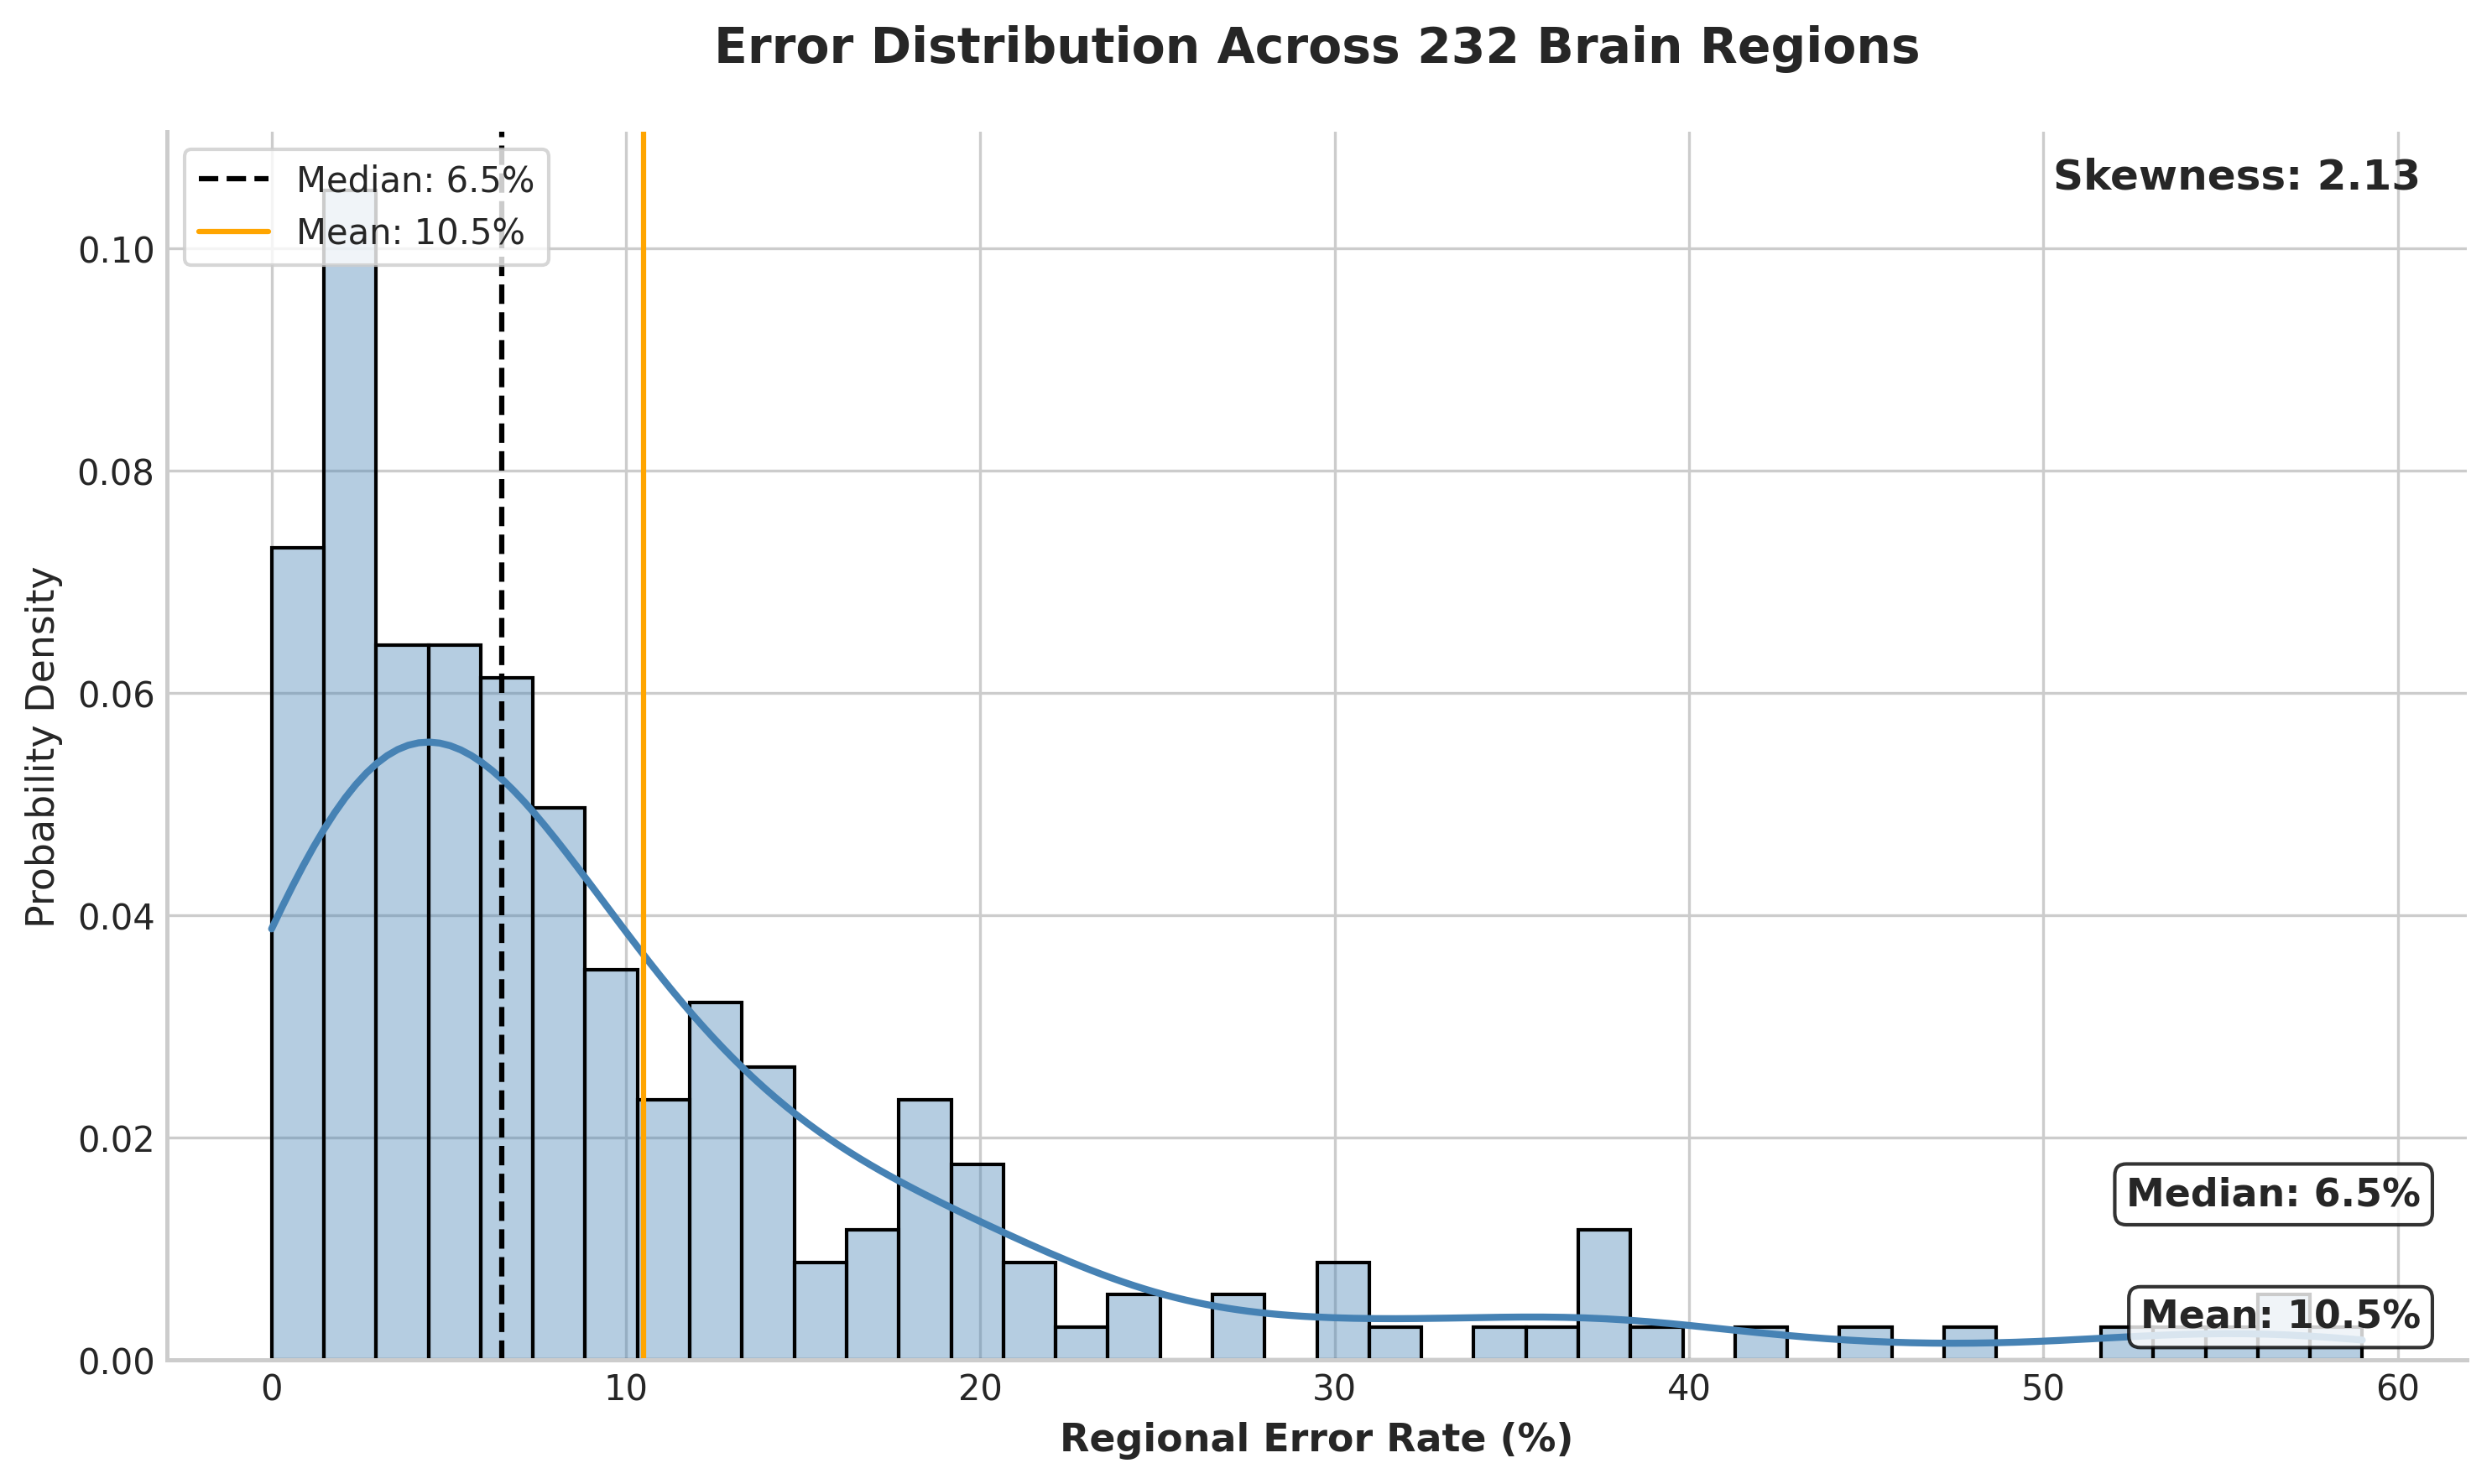

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Simplified publication-ready plot
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(data=meta_df, x='error_rate_pct', bins=40, kde=True, 
             color='steelblue', alpha=0.4, stat='density', 
             line_kws={'lw': 2})

# Reference lines
median_val = meta_df['error_rate_pct'].median()
mean_val = meta_df['error_rate_pct'].mean()
skew_val = stats.skew(meta_df['error_rate_pct'])

ax.axvline(median_val, color='black', linestyle='--', lw=1.5, 
           label=f'Median: {median_val:.1f}%')
ax.axvline(mean_val, color='orange', linestyle='-', lw=1.5, 
           label=f'Mean: {mean_val:.1f}%')

# Skewness top-right
ax.text(0.98, 0.98, f'Skewness: {skew_val:.2f}', transform=ax.transAxes, 
        ha='right', va='top', fontweight='bold', fontsize=12)

# Mean & Median bottom-right (10-20 points above data)
ax.text(0.98, 0.15, f'Median: {median_val:.1f}%', transform=ax.transAxes, 
        ha='right', va='top', fontweight='bold', fontsize=11, 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.text(0.98, 0.05, f'Mean: {mean_val:.1f}%', transform=ax.transAxes, 
        ha='right', va='top', fontweight='bold', fontsize=11, 
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

ax.set_xlabel('Regional Error Rate (%)', fontweight='bold')
ax.set_ylabel('Probability Density')
ax.set_title('Error Distribution Across 232 Brain Regions', 
             fontsize=14, fontweight='bold', pad=20, loc='center')
ax.legend(frameon=True, loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

In [21]:
# total error count and overall error rate across all samples
total_errors = region_error_counts.sum()
total_samples = region_sample_counts.sum()
overall_error_rate = total_errors / total_samples if total_samples > 0 else 0.
print(f"Overall error rate across all samples: {overall_error_rate*100:.4f}% "
      f"({total_errors:,} errors out of {total_samples:,} samples)")

Overall error rate across all samples: 10.4957% (4,870 errors out of 46,400 samples)


## Cell 7 — Table 1: Top 10 Most Reorganized Regions

In [22]:
top10_reorg = (
    meta_df
    .sort_values("error_rate_pct", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10_reorg.index = top10_reorg.index + 1   # rank from 1
top10_reorg.index.name = "Rank"

table1 = top10_reorg[[
    "region_name", "network_8", "hemisphere",
    "error_rate_pct", "error_count", "total_samples"
]].rename(columns={
    "region_name"    : "Region",
    "network_8"      : "Network",
    "hemisphere"     : "Hemisphere",
    "error_rate_pct" : "Error Rate (%)",
    "error_count"    : "Errors",
    "total_samples"  : "Total Samples",
})
table1["Error Rate (%)"] = table1["Error Rate (%)"].round(3)
table1

,Region,Network,Hemisphere,Error Rate (%),Errors,Total Samples
Rank,,,,,,
1,pGP-lh,Subcortical,left,59.0,118,200
2,RH_VisPeri_ExStrSup_3,Visual,right,57.5,115,200
3,RH_VisPeri_ExStrSup_2,Visual,right,56.5,113,200
4,aGP-lh,Subcortical,left,55.0,110,200
5,RH_DefaultA_pCunPCC_1,Default,right,53.5,107,200
6,THA-DP-lh,Subcortical,left,53.0,106,200
7,LH_ContA_Cingm_1,Control,left,48.0,96,200
8,RH_LimbicB_OFC_3,Limbic,right,44.5,89,200
9,LH_LimbicA_TempPole_4,Limbic,left,42.0,84,200


## Cell 8 — Table 2: Top 10 Most Stable Regions

In [23]:
top10_stable = (
    meta_df
    .sort_values("error_rate_pct", ascending=True)
    .head(10)
    .reset_index(drop=True)
)
top10_stable.index = top10_stable.index + 1
top10_stable.index.name = "Rank"

table2 = top10_stable[[
    "region_name", "network_8", "hemisphere",
    "error_rate_pct", "error_count", "total_samples"
]].rename(columns={
    "region_name"    : "Region",
    "network_8"      : "Network",
    "hemisphere"     : "Hemisphere",
    "error_rate_pct" : "Error Rate (%)",
    "error_count"    : "Errors",
    "total_samples"  : "Total Samples",
})
table2["Error Rate (%)"] = table2["Error Rate (%)"].round(3)
table2

,Region,Network,Hemisphere,Error Rate (%),Errors,Total Samples
Rank,,,,,,
1,LH_VisCent_ExStr_4,Visual,left,0.0,0,200
2,LH_SomMotA_4,SomatoMotor,left,0.0,0,200
3,LH_ContA_IPS_1,Control,left,0.0,0,200
4,RH_SomMotA_5,SomatoMotor,right,0.0,0,200
5,RH_DorsAttnA_SPL_2,DorsalAttention,right,0.0,0,200
6,RH_DorsAttnA_ParOcc_1,DorsalAttention,right,0.0,0,200
7,LH_ContA_IPS_3,Control,left,0.5,1,200
8,LH_ContA_IPS_2,Control,left,0.5,1,200
9,LH_DefaultB_PFCd_1,Default,left,0.5,1,200


## Cell 9 — K-Means Clustering on Per-Region Error Rates

In [24]:
X = meta_df["error_rate_pct"].values.reshape(-1, 1)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
labels = kmeans.fit_predict(X)

sil_score = silhouette_score(X, labels)

meta_df["cluster"] = labels

# Label clusters: lower mean = stable (0), higher mean = flexible (1)
cluster_means = meta_df.groupby("cluster")["error_rate_pct"].mean()
stable_cluster   = int(cluster_means.idxmin())
flexible_cluster = int(cluster_means.idxmax())

meta_df["cluster_label"] = meta_df["cluster"].map({
    stable_cluster  : "Stable",
    flexible_cluster: "Flexible",
})

cluster_summary = meta_df.groupby("cluster_label")["error_rate_pct"].agg(
    n="count", mean="mean", std="std"
).round(4)

print(f"Silhouette score : {sil_score:.3f}")
print()
print("Cluster summary:")
print(cluster_summary)
print()

# Network composition of flexible cluster
flex_df = meta_df[meta_df["cluster_label"] == "Flexible"]
flex_net_counts = flex_df["network_8"].value_counts()
print("Flexible cluster — network composition:")
for net, cnt in flex_net_counts.items():
    print(f"  {net:<20}: {cnt}  ({cnt/len(flex_df)*100:.1f}%)")

Silhouette score : 0.763

Cluster summary:
                 n     mean      std
cluster_label                       
Flexible        24  39.7917  11.0708
Stable         208   7.1154   5.7141

Flexible cluster — network composition:
  Subcortical         : 10  (41.7%)
  Visual              : 7  (29.2%)
  Control             : 2  (8.3%)
  Limbic              : 2  (8.3%)
  Default             : 2  (8.3%)
  SomatoMotor         : 1  (4.2%)


## Cell 10 — Network-Level Aggregation (18 fine-grained networks)

In [47]:
# Use the original fine-grained network column from the recall CSV
# For subcortical regions, network column from recall CSV may vary;
# override with 'Subcortical' for those region_idx
meta_df["network_fine"] = meta_df.apply(
    lambda r: "Subcortical" if int(r["region_idx"]) in SUBCORTICAL_IDS else str(r["network"]),
    axis=1
)

net_hierarchy = (
    meta_df.groupby("network_fine")["error_rate_pct"]
    .agg(n_regions="count", mean_error_rate="mean", std_error_rate="std")
    .sort_values("mean_error_rate", ascending=False)
    .reset_index()
)
net_hierarchy["mean_error_rate"] = net_hierarchy["mean_error_rate"].round(4)
net_hierarchy["std_error_rate"]  = net_hierarchy["std_error_rate"].round(4)

# Cohen's d vs Subcortical for each other network
subcort_vals = meta_df.loc[meta_df["network_fine"]=="Subcortical", "error_rate_pct"].values

def cohens_d_welch(a, b):
    pooled_sd = np.sqrt((a.std(ddof=1)**2 + b.std(ddof=1)**2) / 2)
    return (a.mean() - b.mean()) / pooled_sd if pooled_sd > 0 else 0.0

cohens_d_vs_subcort = []
for net in net_hierarchy["network_fine"]:
    if net == "Subcortical":
        cohens_d_vs_subcort.append(np.nan)
    else:
        other_vals = meta_df.loc[meta_df["network_fine"]==net, "error_rate_pct"].values
        cohens_d_vs_subcort.append(round(cohens_d_welch(subcort_vals, other_vals), 2))

net_hierarchy["cohens_d_vs_subcortical"] = cohens_d_vs_subcort
net_hierarchy.index = net_hierarchy.index + 1
net_hierarchy.index.name = "Rank"
net_hierarchy

,network_fine,n_regions,mean_error_rate,std_error_rate,cohens_d_vs_subcortical
Rank,,,,,
1,VisPeri,12,22.0000,19.8838,-0.17
2,Subcortical,32,18.8125,16.5674,NaN
3,LimbicB,6,18.0000,15.3167,0.05
4,LimbicA,8,15.7500,12.7923,0.21
5,VisCent,12,13.4167,12.0375,0.37
6,TempPar,6,12.1667,6.9690,0.52
7,ContB,15,10.7667,9.5616,0.59
8,ContA,16,9.6875,11.2707,0.64
9,DefaultA,14,9.5000,13.3070,0.62


## Cell 11 — One-Way ANOVA Across 8 Network Groups

In [100]:
import numpy as np
from scipy import stats
import pandas as pd

# Step 1: Aggregate subcortical regions into single "Subcortical" category
meta_df['network_18'] = meta_df['network'].copy()

# List of all individual subcortical regions (16 total from your unique() output)
subcortical_regions = [
    'Hippocampus_ant', 'Hippocampus_post', 
    'Amygdala_lat', 'Amygdala_med', 
    'Thalamus_DP', 'Thalamus_VP', 'Thalamus_VA', 'Thalamus_DA',
    'Accumbens_shell', 'Accumbens_core', 
    'Pallidum_post', 'Pallidum_ant', 
    'Putamen_ant', 'Putamen_post', 
    'Caudate_ant', 'Caudate_post'
]

# Replace all subcortical regions with "Subcortical"
meta_df.loc[meta_df['network'].isin(subcortical_regions), 'network_18'] = 'Subcortical'

# Step 2: Verify you now have exactly 18 unique networks
print("Unique network_18 values:", meta_df['network_18'].nunique())
print("network_18 unique:", sorted(meta_df['network_18'].unique()))

# Step 3: Group per-region error rates by the 18 networks
network_18_groups = [
    meta_df.loc[meta_df["network_18"] == net, "error_rate_pct"].values
    for net in meta_df["network_18"].unique()
]

network_18_names = list(meta_df["network_18"].unique())

# Step 4: Run one-way ANOVA
f_stat, anova_p = stats.f_oneway(*network_18_groups)

# Step 5: Calculate eta-squared
all_vals   = meta_df["error_rate_pct"].values
grand_mean = all_vals.mean()
ss_total   = ((all_vals - grand_mean)**2).sum()
ss_between = sum(
    len(g) * (g.mean() - grand_mean)**2 for g in network_18_groups
)
eta_sq = ss_between / ss_total

# Step 6: Degrees of freedom
n_groups = len(network_18_groups)  # Should be 18
df_between = n_groups - 1         # Should be 17
df_within  = len(all_vals) - n_groups

# Step 7: Print results
print(f"\nOne-way ANOVA across {n_groups} network groups (17 Schaefer + 1 Subcortical)")
print(f"  F({df_between},{df_within}) = {f_stat:.2f}")
print(f"  p-value          = {anova_p:.2e}")
print(f"  η²               = {eta_sq:.3f}")

# Optional: Show mean error rates per network (for your table)
network_means = meta_df.groupby('network_18')['error_rate_pct'].agg(['mean', 'std', 'count'])
print("\nNetwork means:")
print(network_means.sort_values('mean', ascending=False))

Unique network_18 values: 18
network_18 unique: ['ContA', 'ContB', 'ContC', 'DefaultA', 'DefaultB', 'DefaultC', 'DorsAttnA', 'DorsAttnB', 'LimbicA', 'LimbicB', 'SalVentAttnA', 'SalVentAttnB', 'SomMotA', 'SomMotB', 'Subcortical', 'TempPar', 'VisCent', 'VisPeri']

One-way ANOVA across 18 network groups (17 Schaefer + 1 Subcortical)
  F(17,214) = 3.49
  p-value          = 9.22e-06
  η²               = 0.217

Network means:
                   mean        std  count
network_18                               
VisPeri       22.000000  19.883753     12
Subcortical   18.812500  16.567433     32
LimbicB       18.000000  15.316658      6
LimbicA       15.750000  12.792297      8
VisCent       13.416667  12.037505     12
TempPar       12.166667   6.968979      6
ContB         10.766667   9.561580     15
ContA          9.687500  11.270722     16
DefaultA       9.500000  13.307025     14
SomMotB        8.066667   6.752953     15
DefaultB       7.205882   7.725888     17
SalVentAttnA   6.250000   4.03

## Cell 12 — Post-Hoc Pairwise t-Tests (Bonferroni-Corrected)

In [108]:
# Fixed version - convert p-values to numeric for sorting
networks_ordered = (
    meta_df.groupby("network_18")["error_rate_pct"]
    .mean()
    .sort_values(ascending=False)
    .index.tolist()
)

n_nets        = len(networks_ordered)  # Should be 18
n_comparisons = n_nets * (n_nets - 1) // 2
alpha_bonf    = 0.05 / n_comparisons

posthoc_rows = []
for i in range(n_nets):
    for j in range(i+1, n_nets):
        net_a = networks_ordered[i]
        net_b = networks_ordered[j]
        vals_a = meta_df.loc[meta_df["network_18"]==net_a, "error_rate_pct"].values
        vals_b = meta_df.loc[meta_df["network_18"]==net_b, "error_rate_pct"].values

        t_val, p_val = stats.ttest_ind(vals_a, vals_b, equal_var=False)
        d_val        = cohens_d_welch(vals_a, vals_b)
        p_bonf       = min(p_val * n_comparisons, 1.0)
        sig          = "***" if p_bonf < 0.001 else "**" if p_bonf < 0.01 else "*" if p_bonf < 0.05 else ""

        posthoc_rows.append({
            "Network A"       : net_a,
            "Network B"       : net_b,
            "Mean A (%)"      : round(np.mean(vals_a), 1),
            "Mean B (%)"      : round(np.mean(vals_b), 1),
            "t"               : round(t_val, 2),
            "p (uncorrected)" : p_val,  # Keep as numeric
            "p (Bonferroni)"  : p_bonf,  # Keep as numeric
            "Cohen's d"       : round(d_val, 2),
            "Significant"     : sig,
        })

table3 = pd.DataFrame(posthoc_rows)

# Convert p-value columns to numeric for sorting
table3['p (uncorrected)'] = pd.to_numeric(table3['p (uncorrected)'])
table3['p (Bonferroni)'] = pd.to_numeric(table3['p (Bonferroni)'])

print(f"18-network post-hoc comparisons (Bonferroni α = 0.05 / {n_comparisons} = {alpha_bonf:.4f})")
sig_count = table3['Significant'].str.len() > 0
print(f"Total pairs: {n_comparisons}, Significant pairs: {sig_count.sum()}")

print("\nTop 10 most significant differences:")
print(table3.nsmallest(10, 'p (Bonferroni)')[['Network A', 'Network B', "Cohen's d", 'Significant']])


18-network post-hoc comparisons (Bonferroni α = 0.05 / 153 = 0.0003)
Total pairs: 153, Significant pairs: 6

Top 10 most significant differences:
      Network A     Network B  Cohen's d Significant
32  Subcortical     DorsAttnA       1.26          **
31  Subcortical     DorsAttnB       1.18          **
30  Subcortical       SomMotA       1.11           *
29  Subcortical      DefaultC       1.15           *
26  Subcortical  SalVentAttnA       1.04           *
27  Subcortical  SalVentAttnB       1.07           *
28  Subcortical         ContC       1.11            
25  Subcortical      DefaultB       0.90            
24  Subcortical       SomMotB       0.85            
0       VisPeri   Subcortical       0.17            


In [111]:
pd.set_option('display.max_rows', None)
table3.head()

,Network A,Network B,Mean A (%),Mean B (%),t,p (uncorrected),p (Bonferroni),Cohen's d,Significant
0,VisPeri,Subcortical,22.0,18.8,0.49,0.627156,1.0,0.17,
1,VisPeri,LimbicB,22.0,18.0,0.47,0.645371,1.0,0.23,
2,VisPeri,LimbicA,22.0,15.8,0.86,0.403648,1.0,0.37,
3,VisPeri,VisCent,22.0,13.4,1.28,0.216971,1.0,0.52,
4,VisPeri,TempPar,22.0,12.2,1.53,0.145528,1.0,0.66,


## Cell 13 — Cortical vs. Subcortical Comparison (Table 4)

In [112]:
cortical_df    = meta_df[meta_df["network_8"] != "Subcortical"]
subcortical_df = meta_df[meta_df["network_8"] == "Subcortical"]

cort_rates  = cortical_df["error_rate_pct"].values
subcort_rates = subcortical_df["error_rate_pct"].values

t_cs, p_cs = stats.ttest_ind(subcort_rates, cort_rates, equal_var=False)
d_cs       = cohens_d_welch(subcort_rates, cort_rates)

# 95% CI for means
def mean_ci(arr):
    se = stats.sem(arr)
    ci = stats.t.interval(0.95, df=len(arr)-1, loc=arr.mean(), scale=se)
    return ci

cort_ci    = mean_ci(cort_rates)
subcort_ci = mean_ci(subcort_rates)

# Proportion of errors
total_purified = n_purified
cort_errors    = int(cortical_df["error_count"].sum())
subcort_errors = int(subcortical_df["error_count"].sum())

table4 = pd.DataFrame([
    {
        "Group"           : "Cortical (Schaefer 200)",
        "N Regions"       : len(cortical_df),
        "Mean Error Rate" : f"{cort_rates.mean():.4f}%",
        "SD"              : f"{cort_rates.std(ddof=1):.4f}%",
        "95% CI"          : f"[{cort_ci[0]:.4f}, {cort_ci[1]:.4f}]",
        "Total Errors"    : f"{cort_errors:,}",
        "% of All Errors" : f"{cort_errors/total_purified*100:.1f}%",
    },
    {
        "Group"           : "Subcortical (Tian 32)",
        "N Regions"       : len(subcortical_df),
        "Mean Error Rate" : f"{subcort_rates.mean():.4f}%",
        "SD"              : f"{subcort_rates.std(ddof=1):.4f}%",
        "95% CI"          : f"[{subcort_ci[0]:.4f}, {subcort_ci[1]:.4f}]",
        "Total Errors"    : f"{subcort_errors:,}",
        "% of All Errors" : f"{subcort_errors/total_purified*100:.1f}%",
    },
]).set_index("Group")

print(f"Independent t-test (Welch): Subcortical vs Cortical error rates")
print(f"  t = {t_cs:.2f},  p = {p_cs:.2e},  Cohen's d = {d_cs:.2f}")
print(f"  Subcortical: {len(subcortical_df)} regions ({len(subcortical_df)/N_REGIONS*100:.1f}%) "
      f"but {subcort_errors/total_purified*100:.1f}% of purified errors")
print()
table4

Independent t-test (Welch): Subcortical vs Cortical error rates
  t = 3.20,  p = 2.96e-03,  Cohen's d = 0.70
  Subcortical: 32 regions (13.8%) but 24.7% of purified errors



,N Regions,Mean Error Rate,SD,95% CI,Total Errors,% of All Errors
Group,,,,,,
Cortical (Schaefer 200),200,9.1650%,10.3884%,"[7.7165, 10.6135]","3,666",75.3%
Subcortical (Tian 32),32,18.8125%,16.5674%,"[12.8393, 24.7857]","1,204",24.7%


## Cell 14 — Subcortical Subregion Breakdown

In [29]:
# Map individual subcortical regions to anatomical subgroups
SUBCORT_GROUP_MAP = {
    "aHIP": "Hippocampus", "pHIP": "Hippocampus",
    "lAMY": "Amygdala",    "mAMY": "Amygdala",
    "THA" : "Thalamus",
    "NAc" : "Striatum",    "aPUT": "Striatum",
    "pPUT": "Striatum",    "aCAU": "Striatum",  "pCAU": "Striatum",
    "pGP" : "Pallidum",    "aGP" : "Pallidum",
}

def subcort_group(region_name):
    name = str(region_name)
    for prefix, group in SUBCORT_GROUP_MAP.items():
        if name.startswith(prefix):
            return group
    return "Other"

subcortical_df = meta_df[meta_df["network_8"] == "Subcortical"].copy()
subcortical_df["subgroup"] = subcortical_df["region_name"].apply(subcort_group)

subcort_breakdown = (
    subcortical_df.groupby("subgroup")["error_rate_pct"]
    .agg(n_regions="count", mean_error_rate="mean", std_error_rate="std")
    .sort_values("mean_error_rate", ascending=False)
    .round(4)
)
subcort_breakdown

,n_regions,mean_error_rate,std_error_rate
subgroup,,,
Pallidum,4,29.7500,31.5079
Thalamus,8,23.3750,19.0258
Amygdala,4,22.1250,12.3043
Hippocampus,4,17.5000,13.1972
Striatum,12,11.4583,7.8348


## Cell 15 — Figure: Violin Plot by 8 Network Groups

/tmp/ipykernel_2972244/3445448115.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_tab10    = plt.cm.get_cmap("tab10", 8)
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none 

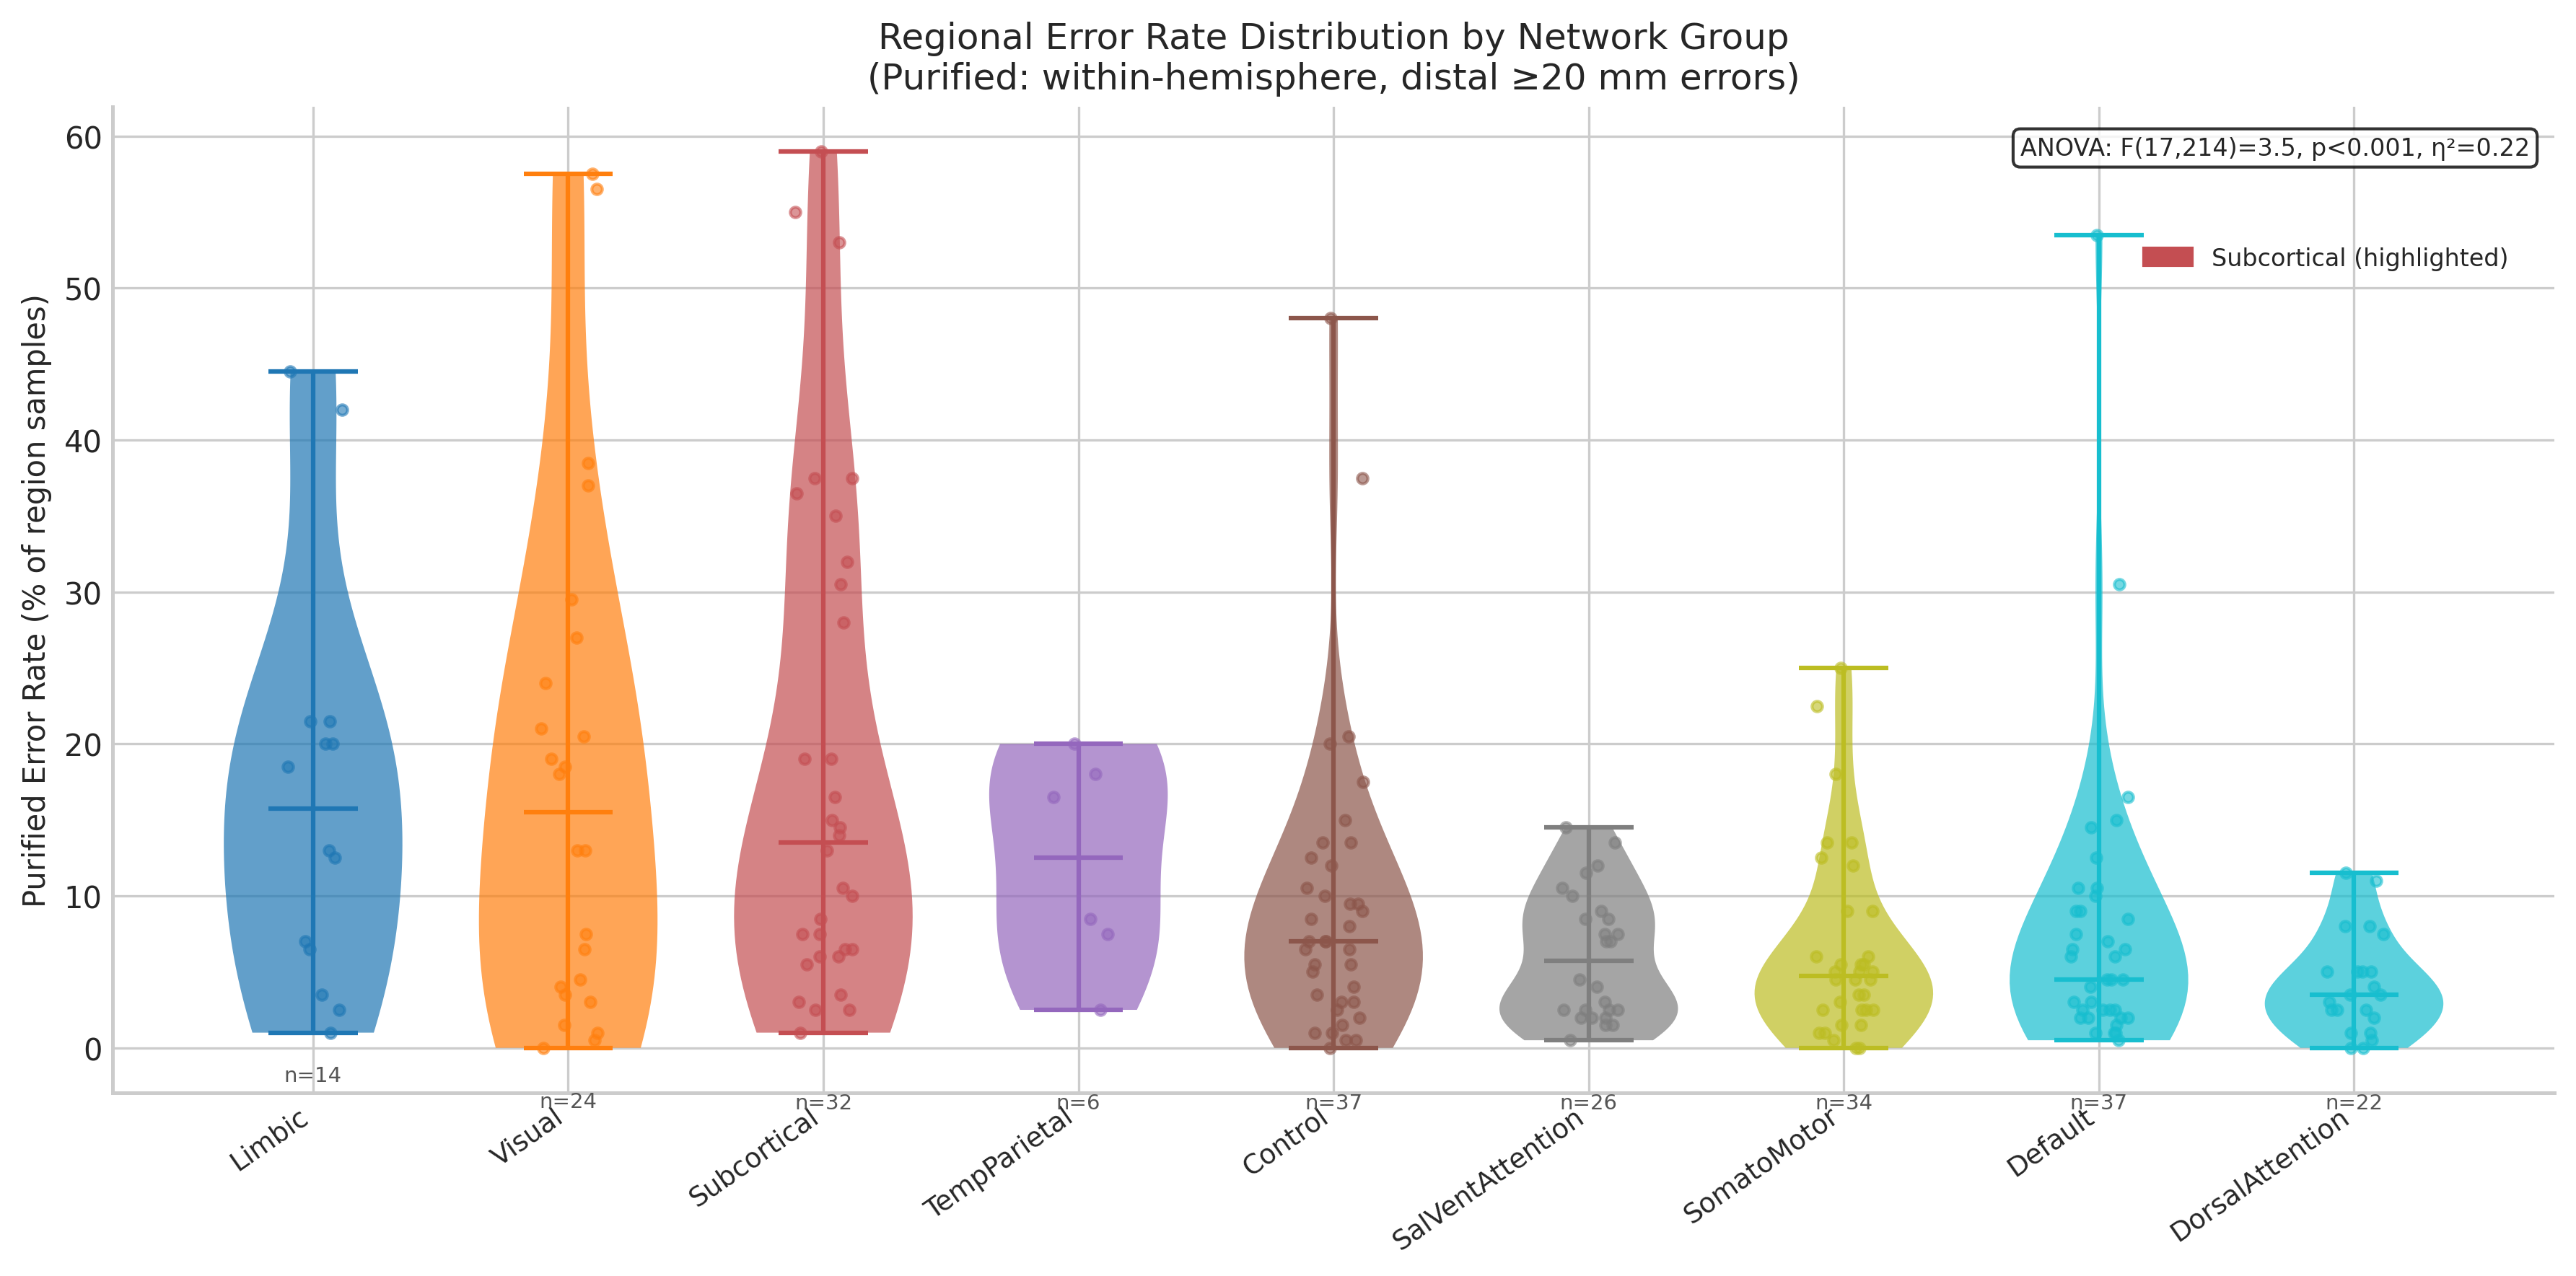

Violin plot saved.


In [113]:
# Sort networks by median error rate (descending) for visual clarity
net_order = (
    meta_df.groupby("network_8")["error_rate_pct"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Colour: Subcortical distinct, cortical networks use tab10
cmap_tab10    = plt.cm.get_cmap("tab10", 8)
net_colors    = {net: cmap_tab10(i) for i, net in enumerate(net_order)}
net_colors["Subcortical"] = "#C44E52"   # highlight subcortical in red

fig, ax = plt.subplots(figsize=(12, 6))

positions = np.arange(len(net_order))

for pos, net in enumerate(net_order):
    vals = meta_df.loc[meta_df["network_8"] == net, "error_rate_pct"].values
    parts = ax.violinplot(
        vals, positions=[pos], widths=0.7,
        showmedians=True, showextrema=True
    )
    color = net_colors[net]
    for pc in parts["bodies"]:
        pc.set_facecolor(color)
        pc.set_alpha(0.7)
    for part_name in ["cmedians", "cmins", "cmaxes", "cbars"]:
        parts[part_name].set_color(color)
        parts[part_name].set_linewidth(1.5)

    # Overlay individual region points
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(pos + jitter, vals, color=color, s=12, alpha=0.6, zorder=3)

    # Annotate n
    ax.text(pos, ax.get_ylim()[0] if ax.get_ylim()[0] else -0.01,
            f"n={len(vals)}", ha="center", va="top", fontsize=7, color="#555")

ax.set_xticks(positions)
ax.set_xticklabels(net_order, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Purified Error Rate (% of region samples)", fontsize=10)
ax.set_title(
    "Regional Error Rate Distribution by Network Group\n"
    "(Purified: within-hemisphere, distal ≥20 mm errors)",
    fontsize=12
)
ax.spines[["top", "right"]].set_visible(False)

# ANOVA result annotation
ax.text(
    0.99, 0.97,
    f"ANOVA: F({df_between},{df_within})={f_stat:.1f}, p<0.001, η²={eta_sq:.2f}",
    transform=ax.transAxes, ha="right", va="top", fontsize=8,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
)

# Cluster legend
legend_patches = [
    mpatches.Patch(color="#C44E52", label="Subcortical (highlighted)"),
]
ax.legend(handles=legend_patches, fontsize=8, loc="upper right",
          bbox_to_anchor=(0.99, 0.88), framealpha=0.8)

fig_dir = ROOT / "analysis/hypothesis_testing/figures"
fig_dir.mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig(fig_dir / "H4_violin_error_rate_by_network.png", dpi=150, bbox_inches="tight")
plt.show()
print("Violin plot saved.")

## Cell 16 — Key Finding Summary

In [31]:
print("=" * 68)
print("KEY FINDING — H4: Regional and Network Reorganization Patterns")
print("=" * 68)
print()
print(f"  Purified error set: {n_purified:,} distal within-hemisphere errors")
print(f"  Per-region error rate: M={er.mean():.4f}%, SD={er.std(ddof=1):.4f}%,"
      f" range [{er.min():.4f}–{er.max():.4f}%]")
print()
print(f"  Network-level heterogeneity:")
print(f"    ANOVA F({df_between},{df_within}) = {f_stat:.2f}, p = {anova_p:.2e}, η² = {eta_sq:.3f}")
print()
print(f"  K-means clustering (k=2):")
print(f"    Silhouette score = {sil_score:.3f}")
stable_row   = cluster_summary.loc["Stable"]
flexible_row = cluster_summary.loc["Flexible"]
print(f"    Stable   cluster: n={int(stable_row['n'])}, "
      f"M={stable_row['mean']:.4f}%, SD={stable_row['std']:.4f}%")
print(f"    Flexible cluster: n={int(flexible_row['n'])}, "
      f"M={flexible_row['mean']:.4f}%, SD={flexible_row['std']:.4f}%")
print()
print(f"  Cortical vs. Subcortical:")
print(f"    t = {t_cs:.2f}, p = {p_cs:.2e}, Cohen's d = {d_cs:.2f}")
print(f"    Subcortical: {len(subcortical_df)} regions "
      f"({len(subcortical_df)/N_REGIONS*100:.1f}% of atlas) "
      f"→ {subcort_errors/total_purified*100:.1f}% of purified errors")
print()
print("  → H4 PARTIALLY SUPPORTED:")
print("    - Sensory-motor stability vs. association not confirmed")
print("    - KEY unexpected finding: Subcortical disproportionate")
print("      reorganization is the dominant pattern")
print("=" * 68)

KEY FINDING — H4: Regional and Network Reorganization Patterns

  Purified error set: 4,870 distal within-hemisphere errors
  Per-region error rate: M=10.4957%, SD=11.8710%, range [0.0000–59.0000%]

  Network-level heterogeneity:
    ANOVA F(8,223) = 6.69, p = 7.48e-08, η² = 0.194

  K-means clustering (k=2):
    Silhouette score = 0.763
    Stable   cluster: n=208, M=7.1154%, SD=5.7141%
    Flexible cluster: n=24, M=39.7917%, SD=11.0708%

  Cortical vs. Subcortical:
    t = 3.20, p = 2.96e-03, Cohen's d = 0.70
    Subcortical: 32 regions (13.8% of atlas) → 24.7% of purified errors

  → H4 PARTIALLY SUPPORTED:
    - Sensory-motor stability vs. association not confirmed
    - KEY unexpected finding: Subcortical disproportionate
      reorganization is the dominant pattern
